## Setup


In [15]:
import sys
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import importlib
import src.baseline_models as bm
importlib.reload(bm)
import src.evaluation as eval
importlib.reload(eval)

<module 'src.evaluation' from '/Users/ranacopty/Desktop/APS360/aps360-movie-flop-predictor/src/evaluation.py'>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from src.baseline_models import (
    create_logistic_regression_pipeline,
    create_majority_baseline)
from src.data_processing import chronological_split
from src.evaluation import (
    evaluate_classifier,
    get_confusion_matrix,
    metrics_to_dataframe)

## Load Processed Data & Chronological Data Split

In [18]:
data_path = project_root / "data/processed/movies_processed.csv"
df = pd.read_csv(data_path)
train, validation, test = chronological_split(df)
print(f"Full dataset: {len(df)}")
print(f"Training: {len(train)}")
print(f"Validation: {len(validation)}")
print(f"Test: {len(test)}")

Full dataset: 857
Training: 559
Validation: 185
Test: 113


## Feature Selection

In [21]:
# strictly pre-release features
numeric_features = [
    "budget",
    "runtime",
    "director_success_ratio",
    "director_prior_count",
    "actor_success_ratio",
    "actor_prior_count"]
categorical_features = ["original_language"]
features = numeric_features + categorical_features
target = "flop"

In [22]:
missing_features = [
    feature for feature in features
    if feature not in df.columns]
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")
print(df[features + [target]].head())

     budget  runtime  director_success_ratio  director_prior_count  \
0  92620000    153.0                1.000000                   0.0   
1  55000000    143.0               10.000000                   1.0   
2  54000000    127.0               10.000000                   1.0   
3  58000000    127.0                4.525884                   5.0   
4  55000000    107.0                1.000000                   0.0   

   actor_success_ratio  actor_prior_count original_language  flop  
0             1.000000                0.0                de     1  
1             1.000000                0.0                en     0  
2             6.381250                2.0                en     0  
3             1.000000                0.0                en     1  
4             1.261958                1.0                en     1  


In [23]:
missing_summary = (
    train[features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
print(missing_summary)

budget                    0
runtime                   0
director_success_ratio    0
director_prior_count      0
actor_success_ratio       0
actor_prior_count         0
original_language         0
dtype: int64


In [24]:
x_train = train[features]
y_train = train[target].astype(int)
x_validation = validation[features]
y_validation = validation[target].astype(int)
x_test = test[features]
y_test = test[target].astype(int)
for split_name, labels in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test)]:
    print(
        f"{split_name}: "
        f"{len(labels)} movies, "
        f"{labels.mean():.1%} flops")

Train: 559 movies, 60.6% flops
Validation: 185 movies, 50.3% flops
Test: 113 movies, 40.7% flops


## Majority-Class Reference

In [25]:
# validation metrics
majority_model = create_majority_baseline()
majority_model.fit(x_train, y_train)
majority_validation_pred = majority_model.predict(x_validation)
majority_validation_metrics = evaluate_classifier(
    y_true=y_validation,
    y_pred=majority_validation_pred)
majority_validation_metrics

{'accuracy': 0.5027027027027027,
 'balanced_accuracy': 0.5,
 'flop_precision': 0.5027027027027027,
 'flop_recall': 1.0,
 'flop_f1': 0.6690647482014388}

## Logistic Regression Baseline

In [26]:
logistic_model = create_logistic_regression_pipeline(
    numeric_features=numeric_features,
    categorical_features=categorical_features)
logistic_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
logistic_validation_pred = logistic_model.predict(x_validation)
logistic_validation_prob = logistic_model.predict_proba(x_validation)[:, 1]
logistic_validation_metrics = evaluate_classifier(
    y_true=y_validation,
    y_pred=logistic_validation_pred,
    y_prob=logistic_validation_prob)
logistic_validation_metrics

{'accuracy': 0.5621621621621622,
 'balanced_accuracy': 0.5617695184665732,
 'flop_precision': 0.5566037735849056,
 'flop_recall': 0.6344086021505376,
 'flop_f1': 0.592964824120603,
 'roc_auc': 0.6085787751285648}

## Quantitative Comparison

In [29]:
comparison = pd.concat(
    [
        metrics_to_dataframe(
            "Majority class",
            majority_validation_metrics,
        ),
        metrics_to_dataframe(
            "Logistic regression",
            logistic_validation_metrics,
        ),
    ],
    ignore_index=True)
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "flop_precision",
    "flop_recall",
    "flop_f1",
    "roc_auc",
]
comparison[metric_columns] = comparison[
    metric_columns
].round(3)
display(comparison)

,model,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc
0,Majority class,0.503,0.500,0.503,1.000,0.669,NaN
1,Logistic regression,0.562,0.562,0.557,0.634,0.593,0.609


## Confusion Matrix

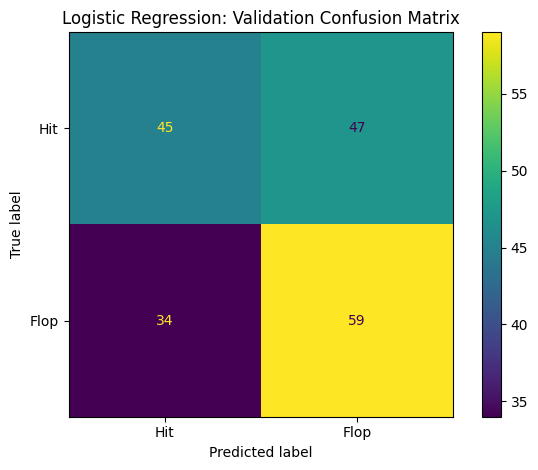

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_validation_pred,
    labels=[0, 1],
    display_labels=["Hit", "Flop"],
    values_format="d")
plt.title("Logistic Regression: Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## Qualitative Prediction Analysis

In [31]:
validation_predictions = validation[
    [
        "title",
        "release_year",
        "budget",
        "runtime",
        "director",
        "lead_actor",
        "director_success_ratio",
        "director_prior_count",
        "actor_success_ratio",
        "actor_prior_count",
        "flop"]
].copy()
validation_predictions["flop_probability"] = (
    logistic_validation_prob)
validation_predictions["predicted_flop"] = (
    logistic_validation_pred)
validation_predictions["correct"] = (
    validation_predictions["flop"]
    == validation_predictions["predicted_flop"])
display(validation_predictions[
        [
            "title",
            "release_year",
            "flop",
            "flop_probability",
            "predicted_flop",
            "correct"]
    ].head(10))

,title,release_year,flop,flop_probability,predicted_flop,correct
559,The Book of Eli,2010,1,0.561308,1,True
560,Edge of Darkness,2010,1,0.517155,1,True
561,Percy Jackson & the Olympians: The Lightning T...,2010,1,0.497582,0,False
562,From Paris with Love,2010,1,0.607183,1,True
563,Valentine's Day,2010,0,0.499086,0,True
564,Shutter Island,2010,0,0.572473,1,False
565,Alice in Wonderland,2010,0,0.465654,0,True
566,How to Train Your Dragon,2010,0,0.543773,1,False
567,Green Zone,2010,1,0.503345,1,True
568,Clash of the Titans,2010,1,0.224994,0,False


In [32]:
correct_flops = validation_predictions[
    (validation_predictions["flop"] == 1)
    & (validation_predictions["predicted_flop"] == 1)
].sort_values("flop_probability", ascending=False)
correct_hits = validation_predictions[
    (validation_predictions["flop"] == 0)
    & (validation_predictions["predicted_flop"] == 0)
].sort_values("flop_probability")
false_positives = validation_predictions[
    (validation_predictions["flop"] == 0)
    & (validation_predictions["predicted_flop"] == 1)
].sort_values("flop_probability", ascending=False)
false_negatives = validation_predictions[
    (validation_predictions["flop"] == 1)
    & (validation_predictions["predicted_flop"] == 0)
].sort_values("flop_probability")

In [34]:
examples = pd.concat(
    [
        correct_flops.head(1).assign(
            prediction_type="Correctly predicted flop"
        ),
        correct_hits.head(1).assign(
            prediction_type="Correctly predicted hit"
        ),
        false_positives.head(1).assign(
            prediction_type="False positive"
        ),
        false_negatives.head(1).assign(
            prediction_type="False negative"
        ),
    ],
    ignore_index=True,
)
display(
    examples[
        [
            "prediction_type",
            "title",
            "release_year",
            "flop",
            "flop_probability",
            "predicted_flop",
            "budget",
            "director_success_ratio",
            "actor_success_ratio",
        ]
    ]
)

,prediction_type,title,release_year,flop,flop_probability,predicted_flop,budget,director_success_ratio,actor_success_ratio
0,Correctly predicted flop,Free Birds,2013,1,0.746361,1,55000000,0.224234,2.311002
1,Correctly predicted hit,The Dictator,2012,0,0.127900,0,65000000,10.000000,10.000000
2,False positive,Ghost Rider: Spirit of Vengeance,2011,0,0.727035,1,57000000,2.040729,2.153623
3,False negative,White House Down,2013,1,0.186210,0,150000000,4.134568,8.105296
